In [3]:
import pandas as pd

In [4]:
import numpy as np

In [6]:
train = pd.read_csv(r"C:\Users\hi\OneDrive\Documents\Working\dataset\train.csv")
test = pd.read_csv(r"C:\Users\hi\OneDrive\Documents\Working\dataset\test.csv")
submission = pd.read_csv(r"C:\Users\hi\OneDrive\Documents\Working\dataset\sample_submission.csv")

In [7]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (22750, 9)
Test shape: (12250, 8)


,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2.0,NaN,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.0,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.0,6.9,0.52


In [8]:
train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22750 entries, 0 to 22749
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee ID           22750 non-null  object 
 1   Date of Joining       22750 non-null  object 
 2   Gender                22750 non-null  object 
 3   Company Type          22750 non-null  object 
 4   WFH Setup Available   22750 non-null  object 
 5   Designation           22750 non-null  float64
 6   Resource Allocation   21369 non-null  float64
 7   Mental Fatigue Score  20633 non-null  float64
 8   Burn Rate             21626 non-null  float64
dtypes: float64(4), object(5)
memory usage: 1.6+ MB


,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
count,22750.000000,21369.000000,20633.000000,21626.000000
mean,2.178725,4.481398,5.728188,0.452005
std,1.135145,2.047211,1.920839,0.198226
min,0.000000,1.000000,0.000000,0.000000
25%,1.000000,3.000000,4.600000,0.310000
50%,2.000000,4.000000,5.900000,0.450000
75%,3.000000,6.000000,7.100000,0.590000
max,5.000000,10.000000,10.000000,1.000000


In [9]:
print(train.isnull().sum())


Employee ID                0
Date of Joining            0
Gender                     0
Company Type               0
WFH Setup Available        0
Designation                0
Resource Allocation     1381
Mental Fatigue Score    2117
Burn Rate               1124
dtype: int64


In [10]:
num_cols = train.select_dtypes(include=np.number).columns

In [11]:
train[num_cols] = train[num_cols].fillna(train[num_cols].median())

In [12]:
cat_cols = train.select_dtypes(include='object').columns
for col in cat_cols:
    train[col] = train[col].fillna(train[col].mode()[0])

In [13]:
print(train.columns)

Index(['Employee ID', 'Date of Joining', 'Gender', 'Company Type',
       'WFH Setup Available', 'Designation', 'Resource Allocation',
       'Mental Fatigue Score', 'Burn Rate'],
      dtype='object')


In [14]:
target = "Burn Rate"

In [16]:
from scipy import stats

In [17]:
stat, p = stats.shapiro(train[target].sample(500))

In [18]:
print("Shapiro Test Statistic:", stat)
print("p-value:", p)

Shapiro Test Statistic: 0.9936206111485448
p-value: 0.03321139816750899


In [19]:
if p > 0.05:
    print("Data is normally distributed (fail to reject H0)")
else:
    print("Data is NOT normally distributed (reject H0)")

Data is NOT normally distributed (reject H0)


In [20]:
import matplotlib.pyplot as plt

In [21]:
import seaborn as sns

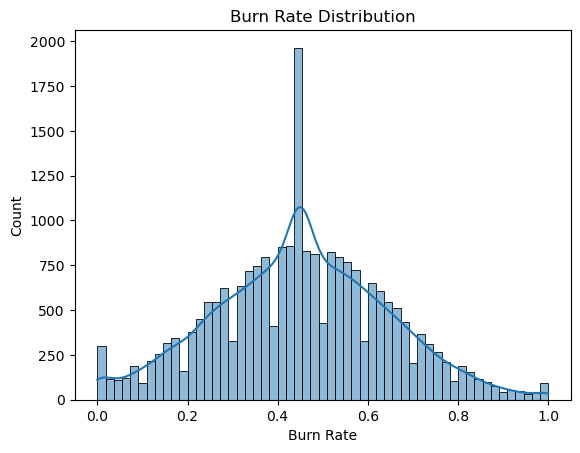

In [22]:
sns.histplot(train[target], kde=True)
plt.title("Burn Rate Distribution")
plt.show()

In [23]:
group1 = train[train["WFH Setup Available"] == "Yes"][target]
group2 = train[train["WFH Setup Available"] == "No"][target]

In [24]:
t_stat, p_val = stats.ttest_ind(group1, group2, nan_policy='omit')

In [25]:
print("T-Statistic:", t_stat)
print("P-value:", p_val)

T-Statistic: -47.188410787471575
P-value: 0.0


In [26]:
if p_val < 0.05:
    print("Reject H0 → Significant difference in burnout")
else:
    print("Fail to reject H0 → No significant difference")

Reject H0 → Significant difference in burnout


In [27]:
groups = [train[train["Designation"] == i][target] for i in train["Designation"].unique()]

In [28]:
f_stat, p_val = stats.f_oneway(*groups)

In [29]:
print("F-Statistic:", f_stat)
print("P-value:", p_val)

F-Statistic: 4935.841852281933
P-value: 0.0


In [30]:
if p_val < 0.05:
    print("Significant difference among groups")
else:
    print("No significant difference")

Significant difference among groups


In [31]:
corr, p_val = stats.pearsonr(train["Resource Allocation"], train[target])

In [32]:
print("Correlation:", corr)
print("P-value:", p_val)

Correlation: 0.8099377611496423
P-value: 0.0


In [33]:
if p_val < 0.05:
    print("Significant correlation exists")
else:
    print("No significant correlation")

Significant correlation exists


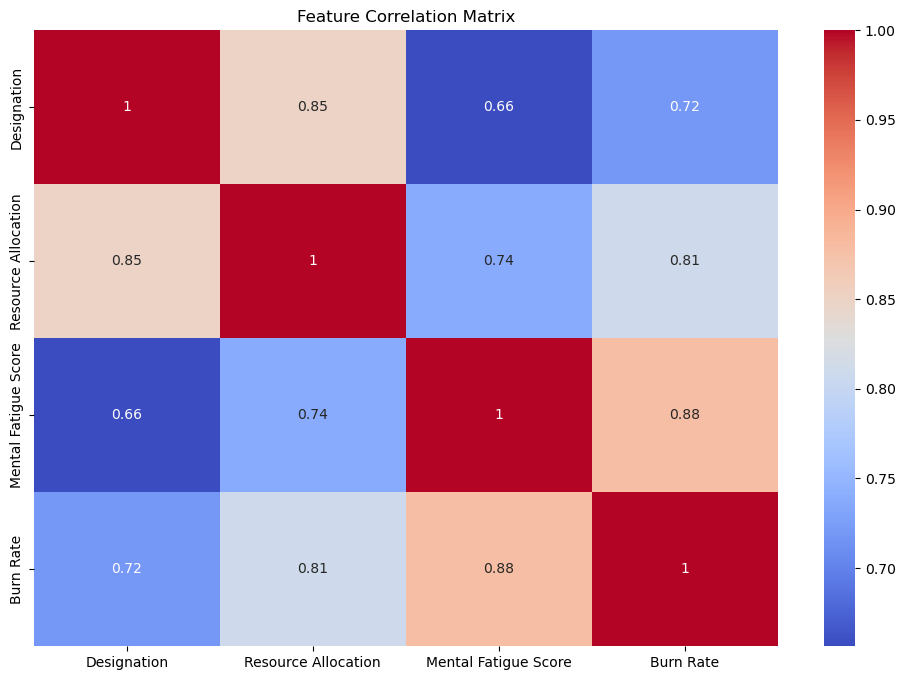

In [49]:
plt.figure(figsize=(12,8))
sns.heatmap(train.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [38]:
features = train.select_dtypes(include=np.number).drop(columns=[target])

In [39]:
X = features

In [40]:
y = train[target]

In [41]:
from sklearn.model_selection import train_test_split

In [42]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


In [43]:
from sklearn.ensemble import RandomForestRegressor

In [44]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [45]:
pred = model.predict(X_val)

In [46]:
from sklearn.metrics import mean_squared_error

In [47]:
print("RMSE:", np.sqrt(mean_squared_error(y_val, pred)))

RMSE: 0.07293269917379339
